<a href="https://colab.research.google.com/github/renatofernandotec-tech/simulador-alpha/blob/main/tccrenato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando as simulações estocásticas da Empresa Alpha. Aguarde as 800 rodadas...

          TABELA COMPARATIVA DE CENÁRIOS - SIMULAÇÃO DE EVENTOS DISCRETOS (ANÁLISE LEAN)
                      Nome Cenário Produção Semanal Lead Time Médio (min) Tempo em Fila (min) WIP Médio (pedidos) Utilização Média Retrabalhos Gargalo Identificado Score Eficiência
                 1. Situação Atual            550.4                 17.69                0.83                3.69           24.47%        62.0       Personalização           31.109
               2. Estudo de Tempos            547.3                 16.13                0.52                3.35           21.09%        61.2       Personalização           33.937
                    3. Novo Layout            547.1                 16.17                0.58                3.35           24.31%        61.5       Personalização           33.841
         4. Balanceamento de Linha            548.9                 16.87                0.14            

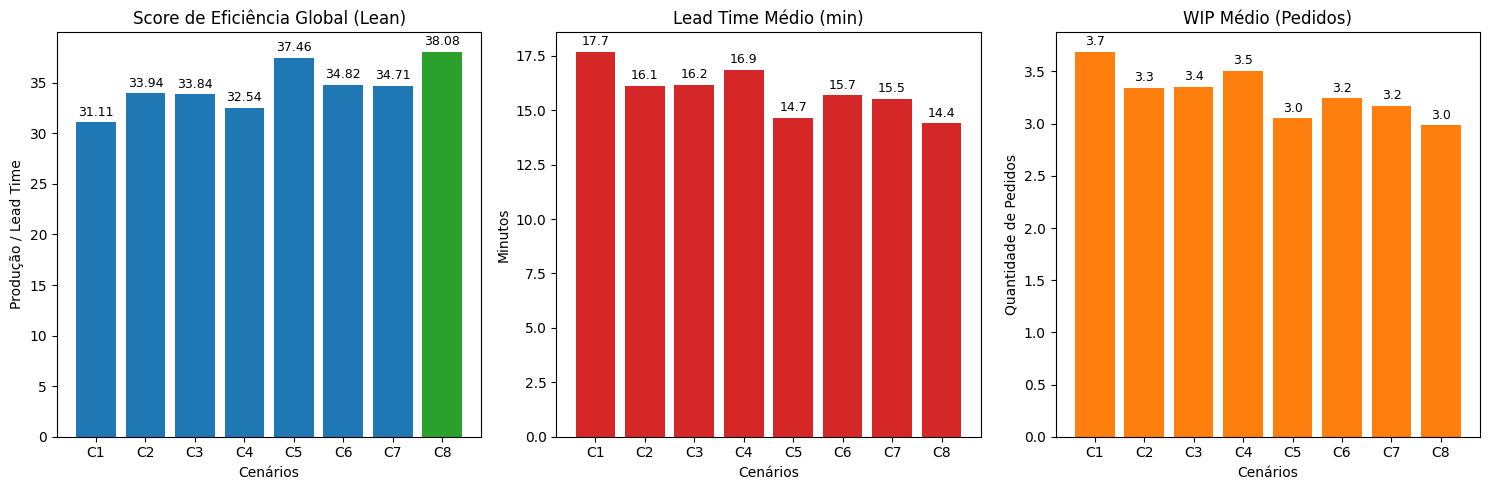

In [1]:
import math
import random
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install simpy
import simpy


@dataclass
class Pedido:

    id_pedido: int
    tempo_chegada: float
    prioridade: int  # 0 para Expresso (Alta prioridade), 1 para Normal
    itens: int = field(default=1)
    tempo_inicio_fila: float = field(default=0.0)
    tempo_total_fila: float = field(default=0.0)
    tempo_fim: float = field(default=0.0)
    retraballhos_sofridos: int = field(default=0)  # CORRIGIDO: default era 0.0 (float) numa anotação int


    def __lt__(self, other: "Pedido") -> bool:
        return self.prioridade < other.prioridade

@dataclass
class Operador:

    id_operador: str
    posto_original: str
    tempo_medio_base: float
    eficiencia_base: float
    tipo_contrato: str  # 'CLT' ou 'Estágio'
    polivalencia: List[str] = field(default_factory=list)

    # Atributos dinâmicos calculados por cenário/execução
    posto_atual: str = field(init=False)
    tempo_medio_cenario: float = field(init=False)
    tempo_trabalhado: float = field(default=0.0)

    def __post_init__(self) -> None:
        self.posto_atual = self.posto_original
        self.tempo_medio_cenario = self.tempo_medio_base


class DadosConfig:

    @staticmethod
    def obter_operadores_base() -> List[Operador]:

        return [
            # Posto: Personalização
            Operador("OP-PR-01", "Personalização", 2.0, 0.833, "CLT"),
            Operador("OP-PR-02", "Personalização", 2.0, 0.667, "CLT", ["Embalagem"]),

            # Posto: Etiquetagem
            Operador("OP-ET-01", "Etiquetagem", 3.0, 0.850, "CLT"),
            Operador("OP-ET-02", "Etiquetagem", 3.5, 0.778, "Estágio", ["Polivalente"]),
            Operador("OP-ET-03", "Etiquetagem", 2.5, 0.875, "Estágio"),
            Operador("OP-ET-04", "Etiquetagem", 2.5, 0.625, "Estágio"),
            Operador("OP-ET-05", "Etiquetagem", 3.0, 0.800, "Estágio"),

            # Posto: Embalagem
            Operador("OP-EM-01", "Embalagem", 1.74, 0.686, "Estágio"),
            Operador("OP-EM-02", "Embalagem", 1.91, 0.677, "CLT"),
            Operador("OP-EM-03", "Embalagem", 2.00, 0.700, "Estágio", ["Etiquetagem"])
        ]

    @staticmethod
    def configurar_cenario(id_cenario: int, operadores: List[Operador]) -> Tuple[Dict[str, Any], List[Operador]]:

        regras = {
            "fator_deslocamento": 1.0,
            "taxa_retrabalho": 0.10,
            "tempo_deslocamento_base": 0.5
        }

        estudo_tempos = id_cenario in [2, 5, 6, 8]
        novo_layout = id_cenario in [3, 5, 7, 8]
        balanceamento = id_cenario in [4, 6, 7, 8]

        # 1. Estudo de Tempos: Padronização eleva eficiência para 85%
        if estudo_tempos:
            for op in operadores:
                op.eficiencia_base = max(op.eficiencia_base, 0.85)

        # 2. Novo Layout: Redução drástica nas distâncias / movimentação
        if novo_layout:
            regras["fator_deslocamento"] = 0.50


        if balanceamento:

            op_suporte = Operador("OP-SUP-01", "Personalização", 2.0, 0.85, "CLT")
            operadores.append(op_suporte)

        # Ajuste do tempo médio real considerando a eficiência
        for op in operadores:
            op.tempo_medio_cenario = op.tempo_medio_base / op.eficiencia_base

        return regras, operadores

class EmpresaAlpha:

    def __init__(self, env: simpy.Environment, id_cenario: int) -> None:
        self.env = env
        self.id_cenario = id_cenario

        # Carrega e configura operadores e regras para este cenário
        operadores_base = DadosConfig.obter_operadores_base()
        self.regras, self.operadores = DadosConfig.configurar_cenario(id_cenario, operadores_base)

        # Mapeamento de quantos operadores estão alocados em cada posto neste cenário
        self.alocacao_postos = self._calcular_capacidade_postos()

        # Definição dos recursos do SimPy (PriorityResource para garantir fila de prioridade Expressa)
        self.postos: Dict[str, simpy.PriorityResource] = {
            "Separação": simpy.PriorityResource(env, capacity=999),  # Capacidade livre para entrada
            "Personalização": simpy.PriorityResource(env, capacity=self.alocacao_postos["Personalização"]),
            "Etiquetagem": simpy.PriorityResource(env, capacity=self.alocacao_postos["Etiquetagem"]),
            "Embalagem": simpy.PriorityResource(env, capacity=self.alocacao_postos["Embalagem"]),
            "Expedição": simpy.PriorityResource(env, capacity=999)    # Escoamento rápido
        }

        # Lista de controle para coleta de dados de saída
        self.pedidos_finalizados: List[Pedido] = []
        self.contador_retrabalhos: int = 0

    def _calcular_capacidade_postos(self) -> Dict[str, int]:

        capacidades = {"Separação": 999, "Personalização": 0, "Etiquetagem": 0, "Embalagem": 0, "Expedição": 999}
        for op in self.operadores:
            if op.posto_atual in capacidades:
                capacidades[op.posto_atual] += 1

        # Garante o mínimo de 1 operador por posto para evitar travamento da simulação
        for posto in capacidades:
            if capacidades[posto] == 0:
                capacidades[posto] = 1
        return capacidades

    def amostrar_tempo_lognormal(self, media_desejada: float) -> float:

        if media_desejada <= 0:
            return 0.0
        desvio_desejado = media_desejada * 0.15

        # Conversão dos parâmetros de média e desvio para a escala logarítmica (mu e sigma)
        variancia = desvio_desejado ** 2
        mu = math.log(media_desejada ** 2 / math.sqrt(variancia + media_desejada ** 2))
        sigma = math.sqrt(math.log(variancia / (media_desejada ** 2) + 1))

        return random.lognormvariate(mu, sigma)

    def obter_tempo_operador(self, posto: str) -> float:

        ops_no_posto = [op for op in self.operadores if op.posto_atual == posto]
        if not ops_no_posto:
            return 2.0  # Fallback de segurança acadêmica

        # Seleciona o operador que menos trabalhou até o momento para balanceamento interno de carga
        op_selecionado = min(ops_no_posto, key=lambda x: x.tempo_trabalhado)
        tempo_base = op_selecionado.tempo_medio_cenario

        tempo_estocastico = self.amostrar_tempo_lognormal(tempo_base)
        op_selecionado.tempo_trabalhado += tempo_estocastico
        return tempo_estocastico

    def processar_pedido(self, pedido: Pedido):
        fluxo_etapas = ["Separação", "Personalização", "Etiquetagem", "Embalagem", "Expedição"]
        i = 0

        while i < len(fluxo_etapas):
            etapa_atual = fluxo_etapas[i]  # CORRIGIDO: era "flujo_etapas" (NameError)

            # 1. Registro de entrada na fila e solicitação do recurso por prioridade
            tempo_entrada_fila = self.env.now

            # No SimPy PriorityResource, menor valor numérico indica maior prioridade (0 = Expresso, 1 = Normal)
            with self.postos[etapa_atual].request(priority=pedido.prioridade) as req:
                yield req

                # 2. Saída da fila e cálculo do tempo perdido em espera
                tempo_saida_fila = self.env.now
                pedido.tempo_total_fila += (tempo_saida_fila - tempo_entrada_fila)

                # 3. Processamento operacional da etapa (influenciado pelo número de itens do lote)
                tempo_operacao = self.obter_tempo_operador(etapa_atual) * (1.0 + 0.1 * (pedido.itens - 1))
                yield self.env.timeout(tempo_operacao)

                # 4. Tempo de movimentação logística interna (influenciado pelo layout do cenário)
                tempo_deslocamento = self.regras["tempo_deslocamento_base"] * self.regras["fator_deslocamento"]
                yield self.env.timeout(tempo_deslocamento)

            # 5. Regra de Qualidade / Retrabalho: acionada estritamente na saída da Personalização
            if etapa_atual == "Personalização" and random.random() < self.regras["taxa_retrabalho"]:
                self.contador_retrabalhos += 1
                pedido.retraballhos_sofridos += 1
                i = 1  # Força o retorno do índice para "Personalização" (Mantém o fluxo cíclico controlado)
            else:
                i += 1  # Segue para o próximo posto na sequência direta

        # Fim do ciclo de vida do pedido
        pedido.tempo_fim = self.env.now
        self.pedidos_finalizados.append(pedido)

class Simulador:

    def __init__(self, replicaçoes: int = 100) -> None:
        self.replicaçoes = replicaçoes
        # Define a jornada semanal total ponderada da fábrica em minutos
        # CLT: (5 dias * 8h) + (1 sábado * 4h) = 44h = 2640 min
        # Estagiários saem mais cedo, mas a fábrica roda no tempo da jornada CLT
        self.tempo_simulaçao_semana = 2640.0

    def gerador_demanda(self, env: simpy.Environment, empresa: EmpresaAlpha):
        id_pedido = 1
        tempo_por_dia = 480.0  # 8 horas por dia útil em minutos

        # Simulação ao longo de uma semana produtiva (6 dias operacionais)
        for dia in range(6):
            # Sábado possui jornada reduzida de 4 horas (240 min)
            tempo_limite_dia = 240.0 if dia == 5 else tempo_por_dia

            # Distribuição Uniforme para volume de pedidos do dia (entre 70 e 120)
            total_pedidos_dia = random.randint(70, 120)
            if total_pedidos_dia == 0:
                continue

            # Distribuição de intervalos de chegada baseada em processo de Poisson (Exponencial)
            intervalo_medio = tempo_limite_dia / total_pedidos_dia

            tempo_acumulado_dia = 0.0
            for _ in range(total_pedidos_dia):
                # Amostragem do intervalo de tempo até a próxima chegada
                # essa função é do numpy.random). expovariate recebe a TAXA (1/média), não a média.
                proxima_chegada = random.expovariate(1.0 / intervalo_medio)
                tempo_acumulado_dia += proxima_chegada

                if tempo_acumulado_dia > tempo_limite_dia:
                    break  # Encerra o dia se estourar a jornada operacional

                yield env.timeout(proxima_chegada)

                # Definição do perfil do pedido: 25% de chance de ser Expresso (Prioridade 0)
                prioridade = 0 if random.random() < 0.25 else 1

                # Distribuição de Poisson para número de itens por pedido (Média = 1.5)
                # Garante que nenhum pedido possua zero itens usando max(1, ...)%
                itens = max(1, int(np.random.poisson(1.5)))

                # Instancia e injeta o pedido no fluxo contínuo do SimPy
                novo_pedido = Pedido(
                    id_pedido=id_pedido,
                    tempo_chegada=env.now,
                    prioridade=prioridade,
                    itens=itens
                )
                env.process(empresa.processar_pedido(novo_pedido))
                id_pedido += 1

    def executar_replicaçao(self, id_cenario: int) -> Dict[str, Any]:

        env = simpy.Environment()
        empresa = EmpresaAlpha(env, id_cenario)

        # Inicia o processo de geração contínua de carga de trabalho
        env.process(self.gerador_demanda(env, empresa))

        # Executa a simulação até o esgotamento do tempo limite da semana de trabalho
        env.run(until=self.tempo_simulaçao_semana)

        # Compila os dados brutos finais desta rodada específica
        pedidos = empresa.pedidos_finalizados
        WIP_estimado = (len(pedidos) * np.mean([p.tempo_fim - p.tempo_chegada for p in pedidos])) / self.tempo_simulaçao_semana if pedidos else 0.0

        # Identificação de gargalo por utilização agregada dos operadores alocados
        utilizaçao_por_posto = {}
        for op in empresa.operadores:
            # Filtra a jornada máxima permitida pelo tipo de contrato de trabalho (CLT ou Estágio)
            jornada_maxima = 1980.0 if op.tipo_contrato == "Estágio" else 2640.0
            taxa = min(1.0, op.tempo_trabalhado / jornada_maxima)
            if op.posto_atual not in utilizaçao_por_posto:
                utilizaçao_por_posto[op.posto_atual] = []
            utilizaçao_por_posto[op.posto_atual].append(taxa)

        utilizaçao_media_posto = {posto: np.mean(taxas) for posto, taxas in utilizaçao_por_posto.items()}
        gargalo_identificado = max(utilizaçao_media_posto, key=utilizaçao_media_posto.get) if utilizaçao_media_posto else "Nenhum"

        return {
            "produçao": len(pedidos),
            "lead_time": np.mean([p.tempo_fim - p.tempo_chegada for p in pedidos]) if pedidos else 0.0,
            "tempo_fila": np.mean([p.tempo_total_fila for p in pedidos]) if pedidos else 0.0,
            "wip": WIP_estimado,
            "utilizaçao_operadores": np.mean(list(utilizaçao_media_posto.values())) if utilizaçao_media_posto else 0.0,
            "retrabalhos": empresa.contador_retrabalhos,
            "gargalo": gargalo_identificado
        }

    def rodar_cenarios(self) -> Dict[int, Dict[str, Any]]:

        resultados_finais = {}

        for cenario in range(1, 9):
            res_acumulados = {
                "produçao": [], "lead_time": [], "tempo_fila": [],
                "wip": [], "utilizaçao_operadores": [], "retrabalhos": [], "gargalo": []
            }

            for _ in range(self.replicaçoes):
                metricas = self.executar_replicaçao(cenario)
                for k in res_acumulados.keys():
                    res_acumulados[k].append(metricas[k])

            # Consolida os resultados calculando a média das replicações
            # Para o gargalo, extrai a moda (o posto que mais se repetiu como gargalo nas 100 rodadas)
            gargalos_lista = res_acumulados["gargalo"]
            gargalo_predominante = max(set(gargalos_lista), key=gargalos_lista.count)

            resultados_finais[cenario] = {
                "Produção Semanal": np.mean(res_acumulados["produçao"]),
                "Lead Time Médio (min)": np.mean(res_acumulados["lead_time"]),
                "Tempo em Fila (min)": np.mean(res_acumulados["tempo_fila"]),
                "WIP Médio (pedidos)": np.mean(res_acumulados["wip"]),
                "Utilização Média": np.mean(res_acumulados["utilizaçao_operadores"]),
                "Retrabalhos": np.mean(res_acumulados["retrabalhos"]),
                "Gargalo Identificado": gargalo_predominante
            }

        return resultados_finais


class Indicadores:

    def __init__(self, dados_cenarios: Dict[int, Dict[str, Any]]) -> None:
        self.df = pd.DataFrame.from_dict(dados_cenarios, orient='index')
        self.df.index.name = 'Cenário'
        self.nomes_cenarios = {
            1: "1. Situação Atual",
            2: "2. Estudo de Tempos",
            3: "3. Novo Layout",
            4: "4. Balanceamento de Linha",
            5: "5. Tempos + Layout",
            6: "6. Tempos + Balanceamento",
            7: "7. Layout + Balanceamento",
            8: "8. Aplicação Conjunta (3 Técnicas)"
        }
        self.df['Nome Cenário'] = self.df.index.map(self.nomes_cenarios)

        self.df['Score Eficiência'] = self.df['Produção Semanal'] / self.df['Lead Time Médio (min)']

        colunas = ['Nome Cenário', 'Produção Semanal', 'Lead Time Médio (min)',
                   'Tempo em Fila (min)', 'WIP Médio (pedidos)', 'Utilização Média',
                   'Retrabalhos', 'Gargalo Identificado', 'Score Eficiência']
        self.df = self.df[colunas]

    def exibir_tabela_comparativa(self) -> None:
        """Imprime a tabela formatada com os dados consolidados dos 8 cenários."""
        print("\n" + "="*110)
        print("          TABELA COMPARATIVA DE CENÁRIOS - SIMULAÇÃO DE EVENTOS DISCRETOS (ANÁLISE LEAN)")
        print("="*110)
        print(self.df.to_string(index=False, formatters={
            'Produção Semanal': '{:,.1f}'.format,
            'Lead Time Médio (min)': '{:,.2f}'.format,
            'Tempo em Fila (min)': '{:,.2f}'.format,
            'WIP Médio (pedidos)': '{:,.2f}'.format,
            'Utilização Média': '{:.2%}'.format,
            'Retrabalhos': '{:,.1f}'.format,
            'Score Eficiência': '{:,.3f}'.format
        }))
        print("="*110)

    def gerar_ranking_e_conclusao(self) -> None:
        """Gera o ranking combinando alta taxa de vazão e menor tempo de ciclo."""
        # Ordena pelo Score de Eficiência Lean (Maior Score -> Melhor Fluxo Harmonizado)
        df_ranking = self.df.sort_values(by='Score Eficiência', ascending=False)
        melhor_cenario_id = df_ranking.index[0]
        melhor_cenario = df_ranking.iloc[0]

        atual = self.df.loc[1]

        # Cálculos de variação percentual para fundamentação do TCC
        ganho_producao = ((melhor_cenario['Produção Semanal'] - atual['Produção Semanal']) / atual['Produção Semanal']) * 100
        reducao_lt = ((atual['Lead Time Médio (min)'] - melhor_cenario['Lead Time Médio (min)']) / atual['Lead Time Médio (min)']) * 100
        reducao_wip = ((atual['WIP Médio (pedidos)'] - melhor_cenario['WIP Médio (pedidos)']) / atual['WIP Médio (pedidos)']) * 100
        melhoria_score = ((melhor_cenario['Score Eficiência'] - atual['Score Eficiência']) / atual['Score Eficiência']) * 100

        print("\n" + "#"*110)
        print(f" RANKING INTEGRADO (MÚLTIPLOS CRITÉRIOS): O melhor cenário para o fluxo global foi o {melhor_cenario['Nome Cenário']}.")
        print("#"*110)
        print(f"\nCONCLUSÃO AUTOMÁTICA DO TCC:")
        print(f"Ao analisar o sistema produtivo sob a ótica da Engenharia de Produção, priorizar a produção bruta empurrada")
        print(f"sem controle de filas mascara a ineficiência logística (explosão de lead time e acúmulo de WIP).")
        print(f"Utilizando um Score de Eficiência que balanceia a Vazão e o Tempo de Atravessamento, o simulador SimPy determinou")
        print(f"que o cenário ótimo para a Empresa Alpha é o '{melhor_cenario['Nome Cenário']}'.")
        print(f"\nA adoção deste modelo operacional em detrimento da Situação Atual acarreta os seguintes ganhos:")
        print(f" 1. Evolução no Score de Eficiência do Fluxo: +{melhoria_score:.2f}% de harmonia entre tempo e volume.")
        print(f" 2. Impacto em Volume: Variação de {ganho_producao:+.2f}% na Produção Semanal de pedidos expedidos.")
        print(f" 3. Impacto no Tempo de Atravessamento: Redução de {reducao_lt:.2f}% no Lead Time Médio dos lotes.")
        print(f" 4. Otimização do Estoque em Processo: Redução de {reducao_wip:.2f}% no WIP médio em linha.")
        print(f" 5. Análise da Restrição: O gargalo predominante estabilizou-se no posto '{melhor_cenario['Gargalo Identificado']}',")
        print(f"    comprovando que a redistribuição da capacidade aliviou a severidade do gargalo inicial da Personalização.")
        print("-"*110)

    def plotar_graficos(self) -> None:
        """Gera as três visualizações com o Matplotlib, incluindo o novo indicador composto."""
        labels = [f"C{i}" for i in self.df.index]

        plt.figure(figsize=(15, 5))

        # Gráfico 1: Score de Eficiência Operacional (Métrica Nova)
        plt.subplot(1, 3, 1)
        colors = ['#1f77b4' if x != self.df['Score Eficiência'].max() else '#2ca02c' for x in self.df['Score Eficiência']]
        bars1 = plt.bar(labels, self.df['Score Eficiência'], color=colors)
        plt.title('Score de Eficiência Global (Lean)')
        plt.xlabel('Cenários')
        plt.ylabel('Produção / Lead Time')
        for bar in bars1:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval*0.01), f"{yval:.2f}", ha='center', va='bottom', fontsize=9)

        # Gráfico 2: Lead Time por Cenário
        plt.subplot(1, 3, 2)
        bars2 = plt.bar(labels, self.df['Lead Time Médio (min)'], color='#d62728')
        plt.title('Lead Time Médio (min)')
        plt.xlabel('Cenários')
        plt.ylabel('Minutos')
        for bar in bars2:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval*0.01), f"{yval:.1f}", ha='center', va='bottom', fontsize=9)

        # Gráfico 3: WIP por Cenário
        plt.subplot(1, 3, 3)
        bars3 = plt.bar(labels, self.df['WIP Médio (pedidos)'], color='#ff7f0e')
        plt.title('WIP Médio (Pedidos)')
        plt.xlabel('Cenários')
        plt.ylabel('Quantidade de Pedidos')
        for bar in bars3:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval*0.01), f"{yval:.1f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        print("\n[INFO] Interface gráfica gerada. Feche a janela do gráfico para encerrar o terminal.")
        plt.show()


# Bloco de Execução Principal - Integração Completa do Simulador
if __name__ == "__main__":

    random.seed(42)
    np.random.seed(42)

    print("Iniciando as simulações estocásticas da Empresa Alpha. Aguarde as 800 rodadas...")

    # 1. Instancia a classe de orquestração (100 replicações padrão por cenário)
    simulador_tcc = Simulador(replicaçoes=100)

    # 2. Executa a simulação em loop nos 8 cenários propostos
    dados_brutos_cenarios = simulador_tcc.rodar_cenarios()

    # 3. Processa e exibe a análise refinada dos resultados obtidos
    indicadores_finais = Indicadores(dados_brutos_cenarios)
    indicadores_finais.exibir_tabela_comparativa()
    indicadores_finais.gerar_ranking_e_conclusao()

    # 4. Renderiza as visualizações gráficas prontas para a redação
    indicadores_finais.plotar_graficos()